# Heart Rate Prediction Project
This notebook performs an analysis and prediction of heart rate using the Framingham dataset.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay


In [19]:
# Load dataset
data=pd.read_csv('framingham.csv')
#print(data)

In [20]:
# Checking for null values
data.isnull()
# Count number of null values in each column
data.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [21]:
# Filling missing values with median - replace those missing entries with the middle value of the existing data in a column.
data.fillna(data.median(numeric_only=True), inplace=True) #Fill null values in all numerical columns
#data.isnull().sum()
#print(data['TenYearCHD'].tolist()) # print one complete column as list #this is our target

In [28]:
# Basic statistics and visualization
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000
mean,0.429245,49.580189,1.979953,0.494104,8.944340,0.029245,0.005896,0.310613,0.025708,236.667689,132.354599,82.897759,25.799005,75.878774,81.600943,0.151887
std,0.495027,8.572942,1.007087,0.500024,11.904777,0.168513,0.076569,0.462799,0.158280,44.328480,22.033300,11.910394,4.070775,12.023937,22.860340,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.077500,68.000000,72.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,144.000000,90.000000,28.032500,83.000000,85.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [29]:
# Basic statistics and visualization

import ipywidgets as widgets
from IPython.display import display


x_dropdown = widgets.Dropdown(
    options=data.columns,
    description='X-axis:'
)

y_dropdown = widgets.Dropdown(
    options=data.columns,
    description='Y-axis:'
)


# 2. Define the plotting function
def plot_columns(x_col, y_col):
    plt.close()
    plt.figure()
    plt.scatter(data[x_col], data[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.show()


# 3. Create interactive dropdown widgets
# Get the list of all column names in the DataFrame
widgets.interact(
    lambda x, y: plt.scatter(data[x], data[y]) or plt.show(),
    x=data.columns,
    y=data.columns
)

interactive(children=(Dropdown(description='x', options=('male', 'age', 'education', 'currentSmoker', 'cigsPer…

<function __main__.<lambda>(x, y)>

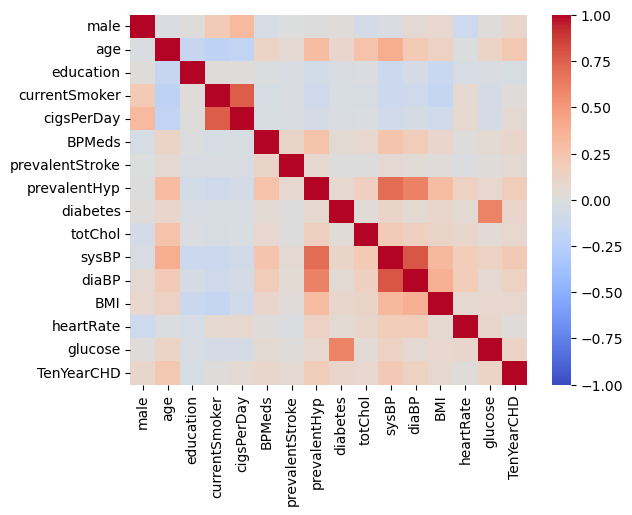

In [6]:
# Correlation heatmap
corr = data.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [7]:
# Define features and target
X=data.drop('TenYearCHD', axis=1) #features
y=data['TenYearCHD']               #label

# Train test split
X_train,X_test,y_train,y_test=train_test_split(
    X, y, 
    test_size=0.2,       # Allocates 20% of data to the test set (a common ratio is 80/20)
    random_state=42,     # Ensures the same split is generated every time the code runs
    shuffle=True         # Shuffles the data before splitting (default behaviour)
)


# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(type(X_train_scaled))
ft_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
ft_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Model training
model = LogisticRegression()
model.fit(ft_train_scaled, y_train)


# Predictions
predictions = model.predict(ft_test_scaled)
y_pred_proba = model.predict_proba(ft_test_scaled)[:, 1]

<class 'numpy.ndarray'>


              precision    recall  f1-score   support

           0       0.86      0.99      0.92       725
           1       0.50      0.07      0.12       123

    accuracy                           0.85       848
   macro avg       0.68      0.53      0.52       848
weighted avg       0.81      0.85      0.80       848

[[717   8]
 [115   8]]


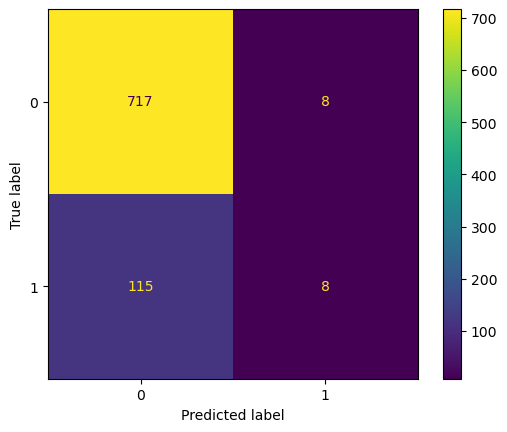

Accuracy: 0.8549528301886793


In [16]:
# Evaluation metrics- classification report, confusion matrix, accuracy score
report = classification_report(y_test, predictions)
print(report)
cm=confusion_matrix(y_test, predictions)
print(cm)
# display confusion matrix
#label= model.labels
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
disp.plot()
plt.show()

#accuracy score
accuracy = accuracy_score(y_test,predictions)
print(f"Accuracy: {accuracy}")

## Conclusion
- We used the Framingham dataset to predict the risk of heart disease within ten years.
- After preprocessing and exploring the dataset, we used logistic regression for prediction.
- The model provides a reasonable accuracy, and the evaluation metrics show potential for use in early detection.
- Further tuning or trying more advanced models could improve performance.
